<a href="https://colab.research.google.com/github/akash-g0807/Numerical-Analysis/blob/main/4_Roots_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Newtons's Method

In [ ]:
def newton(f, fprime, x0, tol=1e-4):
    """
    Find root of f(x) using Newton's Method.
    """

    # Set x equal to initial guess
    x = x0

    # Loop for maximum of 30 iterations
    for i in range(30):

        if abs(f(x)) < tol:
          return x
        # Calculate derivative value
        fp = fprime(x)

        # Avoid division by zero
        if fp == 0:
            return "Method failed: derivative is zero."

        # Newton iteration
        x_new = x - f(x) / fp


        # Update x
        x = x_new

    return "Method did not converge."

In [ ]:
def f(x):
  return x**2 - 4

def fprime(x):
  return 2*x

x_0 = 5

tol=1e-4

print(newton(f,fprime,x_0,tol))

2.0000051812194735


In [ ]:
def newton_with_error_tracking(f, fprime, x0, x_exact, tol=1e-10):
    """
    Find root of f(x) using Newton's Method.
    Returns: (approx_root, errors_list) where errors_list = [|x0-x*|, |x1-x*|, ...]
    """

    errors = []

    # Set x equal to initial guess
    x = x0

    # record error for x0
    errors.append(abs(x - x_exact))

    # Loop for maximum of 30 iterations
    for i in range(30):

        # Calculate derivative value
        fp = fprime(x)

        # Avoid division by zero (or extremely tiny derivative)
        if fp == 0:
            return x, errors

        # Newton iteration
        x_new = x - f(x) / fp

        # record error for x_{n+1}
        errors.append(abs(x_new - x_exact))

        # Check tolerance
        if abs(x_new - x) < tol:
            return x_new, errors

        # Update x
        x = x_new

    # If we exit the loop, method did not converge
    return x, errors

In [ ]:
def f(x):
  return x**2 - 2

def fprime(x):
  return 2*x

x_0 = 1
x_exact = math.sqrt(2)

tol=1e-10

x_new,errors = newton_with_error_tracking(f,fprime,x_0,x_exact,tol)
print(x_new,errors)

1.4142135623730951 [0.41421356237309515, 0.08578643762690485, 0.002453104293571595, 2.1239014147411694e-06, 1.5947243525715749e-12, 0.0]


(np.float64(2.0165021687055735), np.float64(-1.2635157278339633))
2.0165021687055735


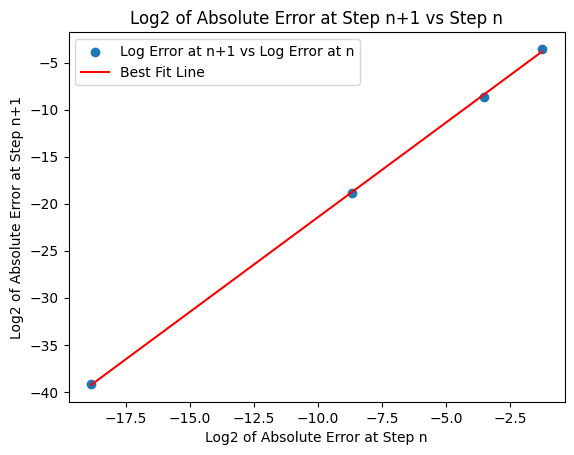

In [ ]:
def plot_error_progression(errors):
    # Calculating the log2 of the absolute error at step n and n+1
    log_errors = np.log2(errors)
    log_errors_n = log_errors[:-1]  # log errors at step n (excluding the last one)
    log_errors_n_plus_1 = log_errors[1:]  # log errors at step n+1 (excluding the first one)

    # Plotting log_errors_n+1 vs log_errors_n
    plt.scatter(log_errors_n, log_errors_n_plus_1, label='Log Error at n+1 vs Log Error at n')

    # Fitting a straight line to the data points
    slope, intercept = np.polyfit(log_errors_n, log_errors_n_plus_1, deg=1)
    print(slope)
    best_fit_line = slope * log_errors_n + intercept
    plt.plot(log_errors_n, best_fit_line, color='red', label='Best Fit Line')

    # Setting up the plot
    plt.xlabel('Log2 of Absolute Error at Step n')
    plt.ylabel('Log2 of Absolute Error at Step n+1')
    plt.title('Log2 of Absolute Error at Step n+1 vs Step n')
    plt.legend()
    plt.show()


def compute_slope_intercept(errors):
    errors = np.array(errors, dtype=float)

    # Remove zeros to avoid log issues
    errors = errors[errors > 0]

    # Form (e_n, e_{n+1}) pairs
    e_n = errors[:-1]
    e_np1 = errors[1:]

    # Take logs (base doesn't matter for slope)
    x = np.log2(e_n)
    y = np.log2(e_np1)

    # Compute slope and intercept
    slope, intercept = np.polyfit(x, y, 1)

    return slope, intercept


errors = [e for e in errors if e > 0]
print(compute_slope_intercept(errors))
plot_error_progression(errors)

1.9903967851640212


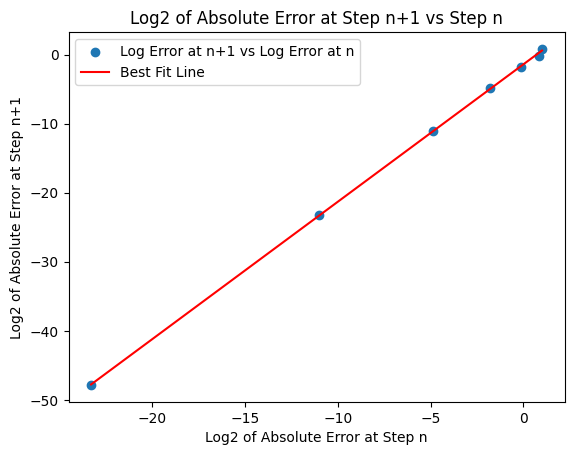

In [ ]:
def f(x):
  return math.exp(x-3) + math.sqrt(x+6) - 4

def fprime(x):
  return math.exp(x-3) + 1/(2*math.sqrt(x+6))

x_0 = 1
x_exact = 3

tol=1e-10

x_new,errors = newton_with_error_tracking(f,fprime,x_0,x_exact,tol)
errors = [e for e in errors if e > 0]
compute_slope_intercept(errors)
plot_error_progression(errors)

# Secant Method

In [ ]:
def secant(f, x_nm1, x_n, tol=1e-10, max_iter=5):

    print(x_nm1)
    print(x_n)
    for _ in range(max_iter):

        f_nm1 = f(x_nm1)
        f_n = f(x_n)

        denominator = f_n - f_nm1
        if denominator == 0:
            raise ZeroDivisionError("Secant method failed: denominator is zero.")

        # Secant update
        x_np1 = x_n - f_n * (x_n - x_nm1) / denominator

        print(x_np1)
        # Check convergence
        if abs(x_np1 - x_n) < tol:
            return x_np1

        # Shift indices
        x_nm1, x_n = x_n, x_np1

    return "Method did not converge"

In [ ]:
def f(x):
    return math.log(x) - math.sin(x)

root = secant(f, x_nm1=1, x_n=5, tol=1e-12)

print("Approx root:", root)

1
5
1.987111031403043
2.2326700487322118
2.2181183722807334
2.21910339602731
2.2191071499595116
Approx root: Method did not converge


In [ ]:
def secant_with_error_tracking(x_exact, f, x_nm1, x_n, tol=1e-10, max_iter=4):

    errors = []

    print(x_nm1)
    print(x_n)

    for _ in range(max_iter):

        f_nm1 = f(x_nm1)
        f_n = f(x_n)

        denominator = f_n - f_nm1
        if denominator == 0:
            raise ZeroDivisionError("Secant method failed: denominator is zero.")

        # Secant update
        x_np1 = x_n - f_n * (x_n - x_nm1) / denominator

        errors.append(abs(x_np1 - x_exact))

        print(x_np1)
        # Check convergence
        if abs(x_np1 - x_n) < tol:
            return x_np1, errors

        # Shift indices
        x_nm1, x_n = x_n, x_np1


    return "Method did not converge", errors

In [ ]:
def f(x):
    return x**2 - 2

x_exact = math.sqrt(2)

root, errors = secant_with_error_tracking(x_exact, f, x_nm1=1, x_n=3, tol=1e-10)

print("Approx root:", root)
print(errors)

1
3
1.25
1.3529411764705883
1.4180790960451977
1.4141280882705685
Approx root: Method did not converge
[0.16421356237309515, 0.06127238590250683, 0.003865533672102517, 8.547410252668364e-05]


(np.float64(1.672614774901627), np.float64(-0.3513102896560952))
1.672614774901627


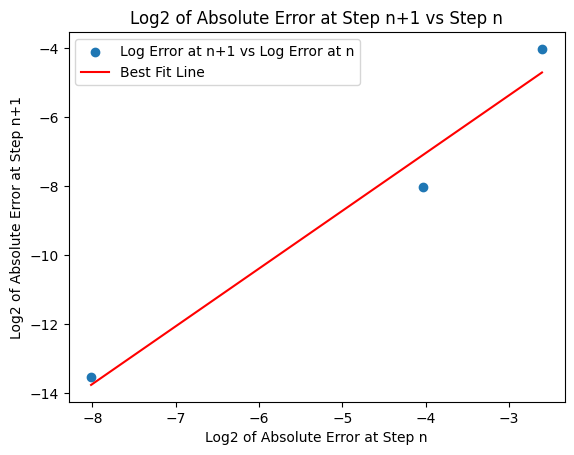

In [ ]:
errors = [e for e in errors if e > 0.0]
print(compute_slope_intercept(errors))
plot_error_progression(errors)